In [17]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../Data/Global_Supply_Chain_2024to2025.csv")
df["Date"] = pd.to_datetime(df["Date"])

df.head()

,Shipment_ID,Date,Origin_Port,Destination_Port,Transport_Mode,Product_Category,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Weather_Condition,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
0,SC-10000,2025-10-16,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,41.39,1
1,SC-10001,2024-04-24,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,40.92,1
2,SC-10002,2024-01-26,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,11.54,0
3,SC-10003,2024-10-08,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,53.13,1
4,SC-10004,2024-09-07,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,0.50,1


In [18]:
print("Target distribution:")
print(df["Disruption_Occurred"].value_counts())

print("\nTarget distribution in percent:")
print(
    df["Disruption_Occurred"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nDataset columns:")
print(df.columns.tolist())

Target distribution:
Disruption_Occurred
1    3063
0    1937
Name: count, dtype: int64

Target distribution in percent:
Disruption_Occurred
1    61.26
0    38.74
Name: proportion, dtype: float64

Dataset columns:
['Shipment_ID', 'Date', 'Origin_Port', 'Destination_Port', 'Transport_Mode', 'Product_Category', 'Distance_km', 'Weight_MT', 'Fuel_Price_Index', 'Geopolitical_Risk_Score', 'Weather_Condition', 'Carrier_Reliability_Score', 'Lead_Time_Days', 'Disruption_Occurred']


In [19]:

target = "Disruption_Occurred"


features = [
    "Date",
    "Origin_Port",
    "Destination_Port",
    "Transport_Mode",
    "Product_Category",
    "Distance_km",
    "Weight_MT",
    "Fuel_Price_Index",
    "Geopolitical_Risk_Score",
    "Weather_Condition",
    "Carrier_Reliability_Score"
]


X = df[features].copy()
y = df[target].copy()

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nExcluded columns: Shipment_ID, Lead_Time_Days")

Feature matrix shape: (5000, 11)
Target vector shape: (5000,)

Features:
['Date', 'Origin_Port', 'Destination_Port', 'Transport_Mode', 'Product_Category', 'Distance_km', 'Weight_MT', 'Fuel_Price_Index', 'Geopolitical_Risk_Score', 'Weather_Condition', 'Carrier_Reliability_Score']

Excluded columns: Shipment_ID, Lead_Time_Days


In [20]:
# Extract calendar features from Date
X["Date_Month"] = X["Date"].dt.month
X["Date_DayOfWeek"] = X["Date"].dt.dayofweek

# Remove the original datetime column
X = X.drop(columns=["Date"])

# Identify numeric and categorical features
numeric_features = X.select_dtypes(include="number").columns.tolist()
categorical_features = X.select_dtypes(include=["object", "str", "category"]).columns.tolist()

print("Updated feature matrix shape:", X.shape)

print("\nNumeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Updated feature matrix shape: (5000, 12)

Numeric features:
['Distance_km', 'Weight_MT', 'Fuel_Price_Index', 'Geopolitical_Risk_Score', 'Carrier_Reliability_Score', 'Date_Month', 'Date_DayOfWeek']

Categorical features:
['Origin_Port', 'Destination_Port', 'Transport_Mode', 'Product_Category', 'Weather_Condition']


In [22]:
data = X.copy()
data["Disruption_Occurred"] = y

# Create reproducible, stratified train/test samples
train_parts = []
test_parts = []

for class_value in data["Disruption_Occurred"].unique():
    class_data = data[data["Disruption_Occurred"] == class_value]

    test_part = class_data.sample(frac=0.20, random_state=42)
    train_part = class_data.drop(index=test_part.index)

    train_parts.append(train_part)
    test_parts.append(test_part)

# Combine and shuffle the samples
train_data = pd.concat(train_parts).sample(frac=1, random_state=42)
test_data = pd.concat(test_parts).sample(frac=1, random_state=42)

# Separate features and target
X_train = train_data.drop(columns=["Disruption_Occurred"])
y_train = train_data["Disruption_Occurred"]

X_test = test_data.drop(columns=["Disruption_Occurred"])
y_test = test_data["Disruption_Occurred"]

print("Training feature set:", X_train.shape)
print("Test feature set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).mul(100).round(2))

Training feature set: (4000, 12)
Test feature set: (1000, 12)

Training target distribution:
Disruption_Occurred
1    61.25
0    38.75
Name: proportion, dtype: float64

Test target distribution:
Disruption_Occurred
1    61.3
0    38.7
Name: proportion, dtype: float64


In [23]:
X_train_encoded = pd.get_dummies(X_train, columns=categorical_features, dtype=int )
X_test_encoded = pd.get_dummies(X_test, columns=categorical_features, dtype=int)

X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

print("Encoded training shape:", X_train_encoded.shape)
print("Encoded test shape:", X_test_encoded.shape)

print("\nFirst encoded columns:")
print(X_train_encoded.columns.tolist()[:20])

Encoded training shape: (4000, 38)
Encoded test shape: (1000, 38)

First encoded columns:
['Distance_km', 'Weight_MT', 'Fuel_Price_Index', 'Geopolitical_Risk_Score', 'Carrier_Reliability_Score', 'Date_Month', 'Date_DayOfWeek', 'Origin_Port_Antwerp', 'Origin_Port_Busan', 'Origin_Port_Dubai', 'Origin_Port_Hamburg', 'Origin_Port_Los Angeles', 'Origin_Port_Rotterdam', 'Origin_Port_Shanghai', 'Origin_Port_Singapore', 'Destination_Port_Antwerp', 'Destination_Port_Busan', 'Destination_Port_Dubai', 'Destination_Port_Hamburg', 'Destination_Port_Los Angeles']


In [24]:
baseline_class = y_train.mode()[0]

baseline_predictions = pd.Series(
    baseline_class, 
    index=y_test.index
)

baseline_accuracy = (baseline_predictions == y_test).mean()

print("Baseline predicted class:", baseline_class)
print(f"Baseline accuracy: {baseline_accuracy:.2%}")

Baseline predicted class: 1
Baseline accuracy: 61.30%


In [25]:
rule_predictions = (
    (X_test["Geopolitical_Risk_Score"] >= 6.67)
    | (X_test["Weather_Condition"].isin(["Hurricane", "Storm"]))
).astype(int)

print("Rule-based predictions:")
print(rule_predictions.value_counts().sort_index())

print("\nNumber of shipments flagged as potentially high risk:")
print(rule_predictions.sum())

print("\nPercentage of test shipments flagged:")
print(f"{rule_predictions.mean():.2%}")

Rule-based predictions:
0    369
1    631
Name: count, dtype: int64

Number of shipments flagged as potentially high risk:
631

Percentage of test shipments flagged:
63.10%


In [26]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": rule_predictions
})

confusion_matrix = pd.crosstab(
    comparison["Actual"],
    comparison["Predicted"],
    rownames=["Actual"],
    colnames=["Predicted"],
    margins=True
)

print("Confusion matrix:")
print(confusion_matrix)

Confusion matrix:
Predicted    0    1   All
Actual                   
0          247  140   387
1          122  491   613
All        369  631  1000


In [27]:
tn = confusion_matrix.loc[0, 0]
fp = confusion_matrix.loc[0, 1]
fn = confusion_matrix.loc[1, 0]
tp = confusion_matrix.loc[1, 1]

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1_score = 2 * (precision * recall) / (precision + recall)

print(f"Accuracy:  {accuracy:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall:    {recall:.2%}")
print(f"F1-score:  {f1_score:.2%}")


Accuracy:  73.80%
Precision: 77.81%
Recall:    80.10%
F1-score:  78.94%


## Regelbasierte Risikoanalyse

Eine Lieferung wird als potenziell risikoreich eingestuft, wenn:
- der geopolitische Risikowert mindestens 6,67 beträgt oder
- die Wetterbedingung „Hurricane“ oder „Storm“ ist.

### Ergebnisse

Die Regel wurde mit 1.000 Testdaten überprüft.

| Kennzahl | Ergebnis |
|---|---:|
| Genauigkeit (Accuracy) | 73,80 % |
| Präzision (Precision) | 77,81 % |
| Trefferquote (Recall) | 80,10 % |
| F1-Score | 78,94 % |

### Einschränkung

Die Regel basiert auf Mustern aus dem vorhandenen Datensatz. Die Ergebnisse sind ein erster Vergleich und keine Garantie für zukünftige Lieferungen.

In [29]:
baseline_tp = ((baseline_predictions == 1) & (y_test == 1)).sum()
baseline_tn = ((baseline_predictions == 0) & (y_test == 0)).sum()
baseline_fp = ((baseline_predictions == 1) & (y_test == 0)).sum()
baseline_fn = ((baseline_predictions == 0) & (y_test == 1)).sum()

baseline_precision = baseline_tp / (baseline_tp + baseline_fp)
baseline_recall = baseline_tp / (baseline_tp + baseline_fn)


baseline_f1 = (
    2 * baseline_precision * baseline_recall
    / (baseline_precision + baseline_recall)
)


results = pd.DataFrame({
    "Baseline": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1
    ],
    "Rule-Based": [
        accuracy,
        precision,
        recall,
        f1_score
    ]
}, index=["Accuracy", "Precision", "Recall", "F1-score"])

results = results * 100

print("Performance comparison (%):")
display(results.round(2))


Performance comparison (%):


,Baseline,Rule-Based
Accuracy,61.30,73.80
Precision,61.30,77.81
Recall,100.00,80.10
F1-score,76.01,78.94


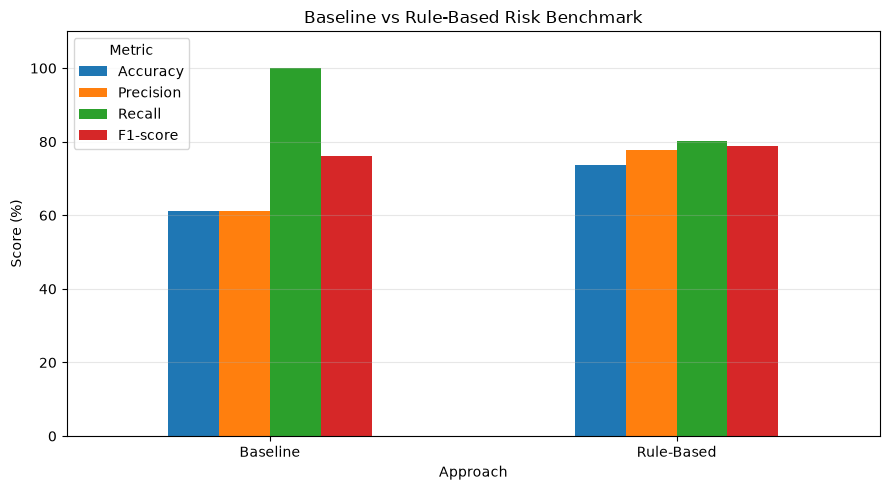

In [30]:
results.T.plot(
    kind="bar",
    figsize=(9, 5),
    ylim=(0, 110),
    rot=0
)

plt.title("Baseline vs Rule-Based Risk Benchmark")
plt.ylabel("Score (%)")
plt.xlabel("Approach")
plt.legend(title="Metric")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [31]:
df["Product_Category"].value_counts()

Product_Category
Electronics        1016
Textiles           1010
Perishables        1009
Pharmaceuticals    1006
Automotive          959
Name: count, dtype: int64

# Gesamtfazit

Die Analyse zeigt, dass mehrere Faktoren mit dem Risiko einer
Lieferunterbrechung zusammenhängen.

Besonders deutlich ist der Zusammenhang mit dem geopolitischen Risiko:
Die Unterbrechungsrate steigt von 47,2 % bei niedrigem Risiko auf
73,1 % bei hohem Risiko.

Auch die Wetterbedingungen spielen eine wichtige Rolle. Bei Stürmen
war die Unterbrechungsrate sehr hoch. Bei Hurrikanen wurden in diesem
Datensatz sogar alle Lieferungen als unterbrochen erfasst.

Die Zuverlässigkeit des Transportdienstleisters zeigt ebenfalls einen
Zusammenhang mit dem Risiko. Bei einer hohen Zuverlässigkeit lag die
Unterbrechungsrate bei 55,8 %, während sie bei einer niedrigen
Zuverlässigkeit 65,0 % betrug.

Bei der Lieferzeit zeigen sich deutliche Unterschiede zwischen den
Transportarten. Lufttransporte hatten die kürzeste mediane Lieferzeit,
während Seetransporte deutlich länger dauerten.

Insgesamt zeigen die Ergebnisse, dass Lieferkettenrisiken nicht nur
von einem einzelnen Faktor abhängen. Besonders die Kombination aus
geopolitischem Risiko und schwierigen Wetterbedingungen kann mit einem
höheren Unterbrechungsrisiko verbunden sein.

Die Ergebnisse können als Grundlage für ein einfaches Frühwarnsystem
dienen. Ein solches System könnte Lieferungen mit erhöhtem Risiko
frühzeitig erkennen und für eine genauere Prüfung priorisieren.


# Empfehlungen

- Lieferungen mit hohem geopolitischem Risiko frühzeitig überwachen.
- Wetterbedingungen bei der Planung und Überwachung berücksichtigen.
- Die Zuverlässigkeit von Transportdienstleistern bei der Auswahl
  und Planung berücksichtigen.
- Besonders riskante Kombinationen von Faktoren genauer prüfen.
- Die regelbasierte Analyse als Unterstützung für die Priorisierung
  verwenden und nicht als automatische Entscheidung.